<a href="https://colab.research.google.com/github/AliffiaHumrh/2311531004_AliffiaHumairah_ImageProcessing/blob/main/Tugas_Pertemuan_4_(1)_Image_Processing_Aliffia_Humairah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

**Penjelasan:**


*   **import cv2**: Library OpenCV untuk pengolahan citra. Di sini hanya digunakan untuk fungsi dasar: cv2.imread (baca citra), cv2.imwrite (simpan citra), dan cv2_imshow (tampil citra di Colab).
*   **import numpy as np**: Library NumPy untuk manipulasi array (misal histogram sebagai array 1D). Digunakan untuk inisialisasi array (np.zeros), operasi matematis (kumulatif sum, pembagian), dan tipe data (dtype=int/float). Ini efisien untuk data numerik seperti gray level (0-255).
*   **import matplotlib.pyplot as plt**: Library Matplotlib untuk visualisasi grafik. Digunakan untuk plot histogram sebagai bar chart (plt.bar, plt.figure, dll.).
*   **from google.colab.patches import cv2_imshow**: Patch khusus Colab untuk ganti cv2.imshow yang error di environment cloud. Ini menampilkan citra sebagai output inline di notebook, tanpa window pop-up.



In [ ]:
# menghitung histogram manual (frekuensi)
def compute_histogram(image):
    hist = np.zeros(256, dtype=int)  # Array untuk 256 level gray
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i, j]] += 1
    return hist

**Penjelasan:**


*   Menghitung histogram asli (frekuensi kemunculan setiap gray level 0-255) secara manual, tanpa library built-in.
*   **hist = np.zeros(256, dtype=int)**: Inisialisasi array histogram dengan 256 elemen (untuk citra 8-bit grayscale, gray level 0-255), semua nilai awal 0. dtype=int untuk hitung integer (frekuensi).
*   **for i in range(image.shape[0])**: Loop baris citra (tinggi, misal 512).
*   **for j in range(image.shape[1])**: Loop kolom citra (lebar, misal 512).
*   **hist[image[i, j]] += 1**: Ambil nilai piksel di posisi (i,j), tambah 1 ke index hist yang sesuai. Misal, jika piksel=128, hist[128] bertambah 1.
*   **return hist**: Kembalikan array histogram.



In [ ]:
# normalisasi histogram (menjadi probabilitas)
def normalize_histogram(hist, total_pixels):
    return hist / total_pixels  # h_i = n_i / n

**Penjelasan:**
*   Mengubah histogram frekuensi menjadi probabilitas relatif (Probability Density Function - PDF). Ini langkah kunci untuk analisis histogram di modul halaman 30-32: $  h_i = \frac{n_i}{n}  $, di mana n = total piksel.
*   **return hist / total_pixels**: Pembagian array NumPy otomatis (element-wise), menghasilkan array float (probabilitas 0-1). Misal, jika hist[128]=10000 dan total_pixels=262144, h_128=0.038.

In [ ]:
# histogram equalization manual
def histogram_equalization(image, hist):
    # Hitung CDF dari histogram asli (bukan normalized, tapi kita normalisasi implisit di CDF)
    cdf = np.zeros(256, dtype=float)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    # Normalisasi CDF: cdf_normalized = cdf / total_pixels
    total_pixels = image.shape[0] * image.shape[1]
    cdf_normalized = cdf / total_pixels

    # Transformasi: new_value = round(cdf_normalized * 255)
    equalized_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            equalized_image[i, j] = np.round(cdf_normalized[image[i, j]] * 255)

    return equalized_image

**Penjelasan:**

Melakukan histogram equalization manual untuk meningkatkan kontras. Ini sesuai modul halaman 45-46: Menggunakan CDF untuk petakan gray level agar distribusi merata (uniform).

In [ ]:
# plot histogram menggunakan Matplotlib
def plot_histogram(hist, title, is_normalized=False):
    plt.figure()
    plt.bar(range(256), hist, width=1.0)
    plt.title(title)
    plt.xlabel('Gray Level')
    plt.ylabel('Probability' if is_normalized else 'Frequency')
    plt.show()

**Penjelasan:**

Visualisasi histogram sebagai bar chart.


*   **lt.figure()**: Buat figure baru untuk plot.
*   **plt.bar(range(256), hist, width=1.0)**: Gambar batang untuk 256 gray level, tinggi batang dari hist, lebar 1 (rapat).
*   **plt.title(title)**: Judul plot (misal 'Histogram Sebelum Normalisasi').
*   **plt.xlabel('Gray Level')**: Label sumbu X (0-255).
*   **plt.ylabel('Probability' if is_normalized else 'Frequency')**: Label Y kondisional: 'Probability' untuk normalized (0-1), 'Frequency' untuk asli.
*   **plt.show()**: Tampilkan plot di Colab/output.


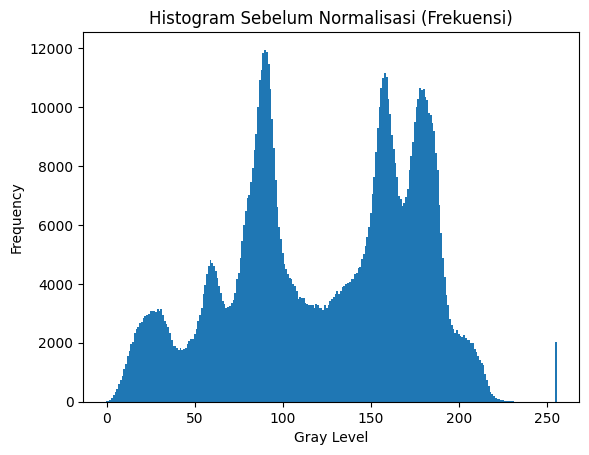

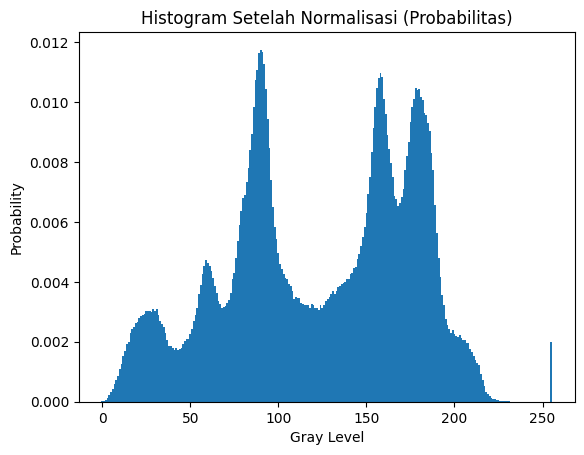

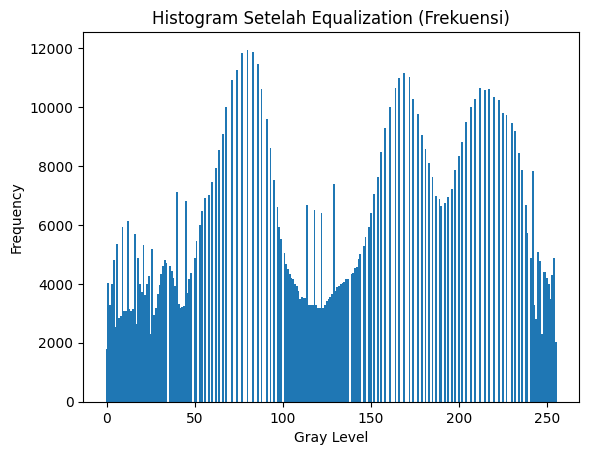

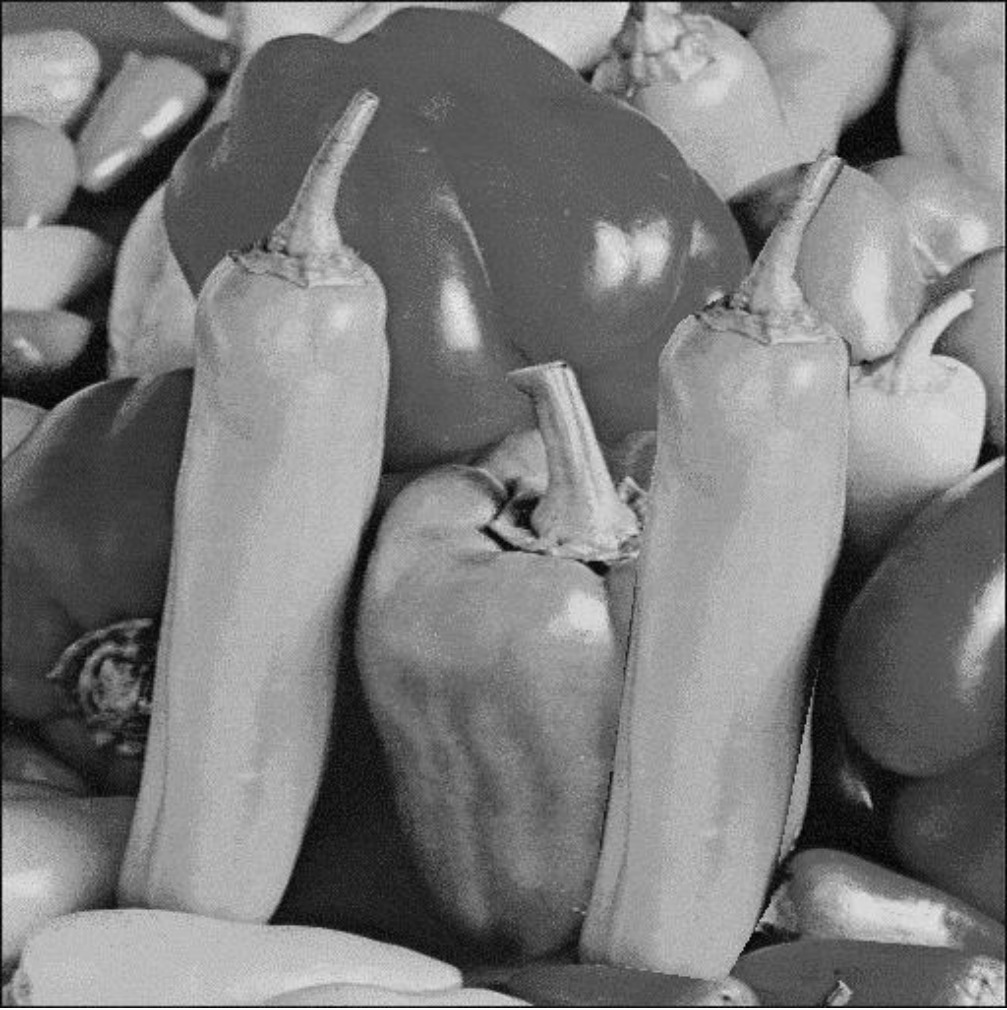

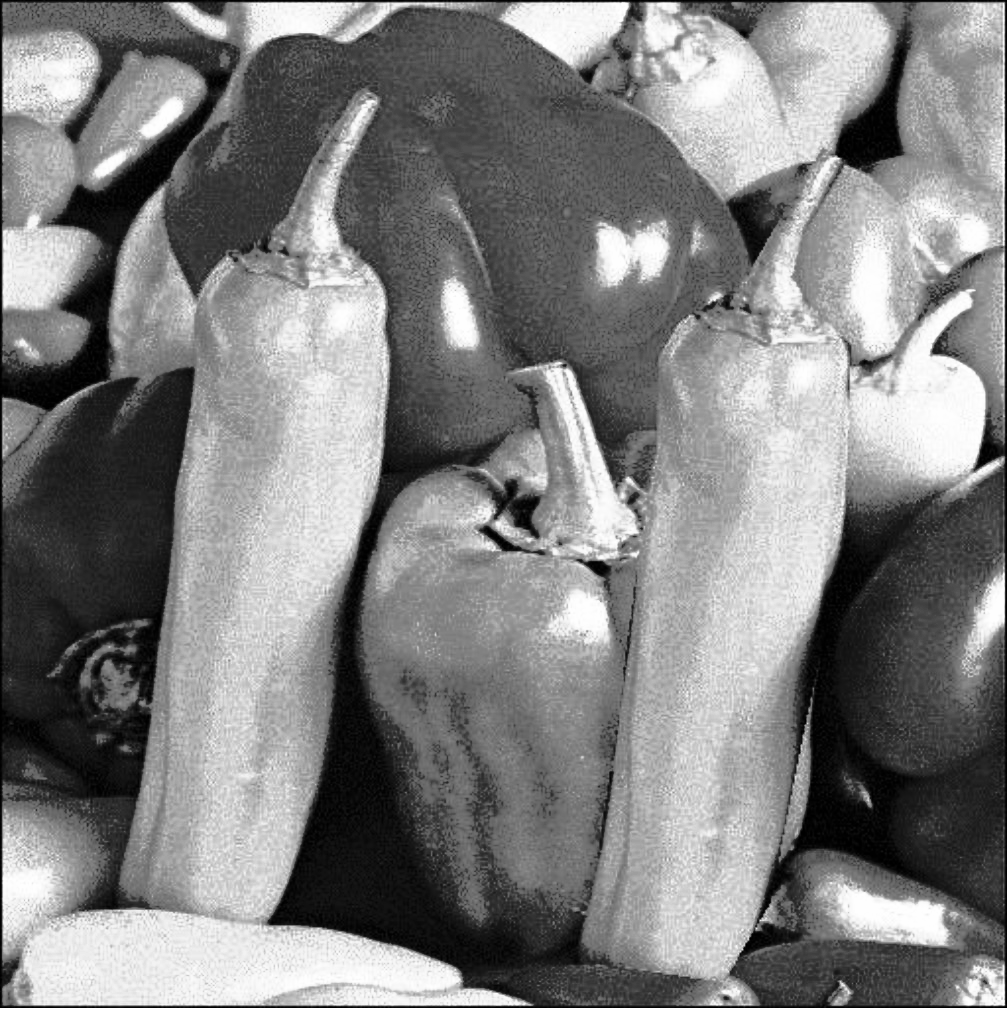

In [ ]:
if __name__ == "__main__":
    image_path = 'gambar1.jpg'
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error: Citra tidak ditemukan!")
        exit()

    # Hitung total pixels
    total_pixels = image.shape[0] * image.shape[1]

    # Hitung histogram asli dan tampilkan
    hist_original = compute_histogram(image)
    plot_histogram(hist_original, 'Histogram Sebelum Normalisasi (Frekuensi)')

    # Normalisasi histogram dan tampilkan
    hist_normalized = normalize_histogram(hist_original, total_pixels)
    plot_histogram(hist_normalized, 'Histogram Setelah Normalisasi (Probabilitas)', is_normalized=True)

    # Lakukan histogram equalization setelah normalisasi (menggunakan hist_original untuk CDF)
    equalized_image = histogram_equalization(image, hist_original)

    # Hitung histogram setelah equalization
    hist_equalized = compute_histogram(equalized_image)
    plot_histogram(hist_equalized, 'Histogram Setelah Equalization (Frekuensi)')

    # Tampilkan citra asli dan setelah equalization
    cv2_imshow(image)
    cv2_imshow(equalized_image)

    # Simpan hasil
    cv2.imwrite('equalized_image.jpg', equalized_image)

**Penjelasan:**

**1. Kode**

*   **if __name__ == "__main__":**: Blok utama agar kode bisa diimport sebagai modul tanpa jalankan main.
*   image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE): baca image sebagai grayscale. Jika file tak ada, print error dan exit.
*   total_pixels: Untuk normalisasi.
*   Normalisasi: Hitung hist_original, plot; normalisasi, plot.
*   Equalization: Panggil fungsi equalization (pakai hist_original), hitung hist_equalized baru, plot.
*   cv2_imshow(image) dan cv2_imshow(equalized_image) untuk menampilkan citra.
*   Simpan: cv2.imwrite simpan citra hasil.

**2. Output**

**a. Histogram Sebelum Normalisasi (Frekuensi) (Plot pertama, judul "Histogram Sebelum Normalisasi (Frekuensi)")**

Bar chart biru dengan sumbu X "Gray Level" (0-250), Y "Frequency" (0-12000). Ada dua puncak utama: Satu tinggi di sekitar gray level 50-100 (frekuensi sekitar 12000), dan satu lagi di 150-200 (frekuensi sekitar 10000). Ada lembah di tengah (sekitar 100-150) dan tail kecil di ujung kanan (~250). Ini histogram asli citra, menunjukkan frekuensi kemunculan setiap gray level. Puncak bimodal mengindikasikan citra dengan dua kelompok intensitas: Area gelap (low gray, misal bayangan peppers) dan terang (high gray, misal highlight buah). Kontras sedang, karena distribusi tidak terlalu sempit tapi belum merata cocok untuk enhancement.

**b. Histogram Setelah Normalisasi (Probabilitas) (Plot kedua, judul "Histogram Setelah Normalisasi (Probabilitas)")**

Bentuk sama seperti sebelumnya (bimodal dengan puncak di 50-100 dan 150-200), tapi sumbu Y "Probability" (0-0.012). Frekuensi dibagi total piksel, jadi nilai kecil (misal puncak ~0.012 berarti ~1.2% piksel di gray level itu). Ini histogram ternormalisasi (PDF), di mana setiap nilai adalah probabilitas relatif. Tidak ubah bentuk, tapi skalanya 0-1 untuk analisis independen ukuran citra. Sum seluruh probabilitas =1. Dari output ini, citra punya distribusi tidak uniform siap untuk equalization agar lebih rata.

**c. Histogram Setelah Equalization (Frekuensi) (Plot ketiga, judul "Histogram Setelah Equalization (Frekuensi)")**

 Bar chart dengan distribusi lebih lebar/merata dari 0-250, tapi ada spikes/garis tipis (frekuensi ~12000 di beberapa level, valley di tengah ~100-150). Tidak lagi bimodal ketat, lebih seperti uniform dengan variasi. Ini histogram citra setelah enhancement. Equalization meratakan distribusi gray level, meningkatkan kontras: Detail gelap jadi lebih gelap, terang lebih terang. Spikes karena gray level jarang "dirapatkan" (gabung), sering "dijauhkan" (lebar). Hasil: Citra lebih jelas, cocok untuk segmentasi atau analisis.

** d. Citra Asli (Gambar pertama, peppers grayscale)**

Foto sayuran (peppers, tomat, dll.) dalam grayscale. Kontras rendah: Area gelap (bayangan) kurang detail, terang (buah) agak pudar, keseluruhan "kabur". Citra input sebelum enhancement. Histogram bimodal menunjukkan kontras sedang, tapi bisa ditingkatkan.

**e. Citra Setelah Equalization (Gambar kedua)**

Sama objek, tapi kontras tinggi: Bayangan lebih gelap (detail muncul), highlights lebih cerah, tekstur buah lebih tajam. Hasil enhancement: Lebih mudah interpretasi (misal deteksi objek peppers). Ini bukti equalization sukses.